# Optimising the previous supervised models 

**Prerequisite:** `02_supervised_sklearn.ipynb` must have been run as this is the notebook that loads its baseline metrics for comparison.

## What this notebook does: 

| Step | What | Why |
|---|---|---|
| 1 | **Extra feature engineering** | 6 new interaction and ratio features that fix known weaknesses in the 38-feature set |
| 2 | **Hyperparameter tuning** | `RandomizedSearchCV` with 5-fold stratified CV on LR, RF, and GB |
| 3 | **XGBoost** | Gradient boosting with L1/L2 regularisation, column subsampling, and `min_child_weight` which is proven to be almost always stronger than sklearn's `GradientBoostingClassifier` |
| 4 | **Comparison** | All tuned models vs notebook 02 baseline |

## Baseline recap for reference:

| Model | ROC-AUC | Recall (churn) | F1 (churn) |
|---|---|---|---|
| Logistic Regression | 0.8273 | 0.685 | 0.604 |
| Random Forest | 0.8187 | 0.666 | 0.606 |
| Gradient Boosting | 0.8227 | 0.725 | 0.600 |

## Why the baseline results were underwhelming?

Two specific problems in the existing 38 features:

**Problem 1 — `num_add_on_services` is non-monotonic.**  
0 services -> 21.5% churn, but 1 service -> 45.8% churn (higher!). This happens because customers with **no internet service** land in the 0-service bucket. They're mostly basic phone-only customers on longer contracts with very low churn (~6%). They pull the bucket average way down, masking that internet customers with zero add-ons are actually very high risk. The model sees 0 services = low risk, which is backwards for internet customers.

**Problem 2 — `charges_to_avg_ratio` has near-zero variance (std ≈ 0.05).**  
Because `TotalCharges ≈ tenure × MonthlyCharges` for most customers, `TotalCharges / tenure ≈ MonthlyCharges`. So the ratio is almost always ≈ 1.0 and carries almost no signal. It's a wasted feature slot.

The new features below directly target both of these issues.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

PROJECT_ROOT  = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
SPLITS_DIR    = PROCESSED_DIR / 'splits'
MODELS_DIR    = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('XGBoost version :', xgb.__version__)
print('Project root    :', PROJECT_ROOT)

XGBoost version : 3.2.0
Project root    : C:\Users\Ahana\Desktop\telco-churn-ml-lab


## Starting off with Extra Feature Engineering to optimise the already built models

We reload `telco_featured.csv` (the output of `01a_feature_engineering.ipynb`), add 6 new features, then re-run the same train/test split + SMOTE + scaling pipeline with **`random_state=42`** so the split is identical to notebook 02.

### New features at a glance

| Feature | Type | Signal it captures |
|---|---|---|
| `fiber_no_protection` | Binary | Fiber optic + no security/backup/support add-ons — high bill, no stickiness |
| `fiber_month_to_month` | Binary | Fiber optic + month-to-month — the two strongest individual predictors combined |
| `contract_payment_risk` | Binary | Month-to-month + electronic check — double volatility signal |
| `internet_no_addons` | Binary | Has internet but zero add-on services — **fixes the non-monotonic `num_add_on_services` problem** |
| `charge_per_service` | Continuous | `MonthlyCharges / (num_add_on_services + 1)` — perceived value; higher = worse value |
| `paperless_no_auto` | Binary | Paperless billing + manual payment — digital but not auto-committed |

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'telco_featured.csv')

# Casting boolean columns that newer pandas produces from get_dummies
bool_cols = df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)

print(f'Loaded: {df.shape}  ({df.shape[1] - 1} features + 1 target)')
df.head(2)

Loaded: (7032, 39)  (38 features + 1 target)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,early_tenure,high_risk_combo,contract_encoded,internet_dsl,internet_fiber_optic,internet_no,payment_bank_transfer_automatic,payment_credit_card_automatic,payment_electronic_check,payment_mailed_check
0,0,0,1,0,1,0,0,0,1,0,...,1,1,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,1,1,0,0,0,0,0,1


### Features 1 & 2 — Fiber-specific risk flags

Fiber optic is the most expensive internet tier and also has the highest churn rate (~42% standalone). It is the segment where customers are most likely to feel they are overpaying, especially if they signed up with no security or support add-ons. Two features are created to isolate this:

- **`fiber_no_protection`**: Fiber optic AND no protective services. These customers pay a premium but have no security, backup, or tech support add-ons that are low switching cost combined with high bill.
- **`fiber_month_to_month`**: Fiber optic AND month-to-month contract. Both are individually the top predictors of churn. A linear model can partially detect each, but the *interaction* - being in both categories simultaneously, is multiplicatively more dangerous than either alone.

In [4]:
feat = df.copy()

# 1. Fiber optic + no protective services (high bill, no stickiness)
feat['fiber_no_protection'] = (
    (feat['internet_fiber_optic'] == 1) & (feat['has_protective_services'] == 0)
).astype(int)

# 2. Fiber optic + month-to-month (intersection of two top-churn predictors)
feat['fiber_month_to_month'] = (
    (feat['internet_fiber_optic'] == 1) & (feat['is_month_to_month'] == 1)
).astype(int)

print('Churn rates for new fiber features:')
for col in ['fiber_no_protection', 'fiber_month_to_month']:
    rates = feat.groupby(col)['Churn'].mean().round(3)
    sizes = feat[col].value_counts().to_dict()
    print(f'  {col}:')
    print(f'    0 -> {rates.get(0, 0):.1%}  (n={sizes.get(0, 0):,})')
    print(f'    1 -> {rates.get(1, 0):.1%}  (n={sizes.get(1, 0):,})')

Churn rates for new fiber features:
  fiber_no_protection:
    0 -> 21.5%  (n=6,184)
    1 -> 63.6%  (n=848)
  fiber_month_to_month:
    0 -> 14.4%  (n=4,904)
    1 -> 54.6%  (n=2,128)


### Features 3 & 4 — Double-risk combinations

- **`contract_payment_risk`**: Month-to-month contract AND electronic check. Month-to-month means no long-term commitment; electronic check means the customer actively pays each billing cycle (no auto-pay friction). Both independently predict churn. Together they identify a customer with both zero contractual lock-in and zero payment inertia.

- **`internet_no_addons`**: Has internet (DSL or fiber) AND zero add-on services. This is the surgical fix for the `num_add_on_services` non-monotonic problem described above. By separating internet customers with 0 services from the "no internet at all" group, the model gets a clean signal: *internet customer with nothing extra* = high risk.

In [5]:
# 3. Month-to-month + electronic check (no contractual or payment commitment)
feat['contract_payment_risk'] = (
    (feat['is_month_to_month'] == 1) & (feat['is_electronic_check'] == 1)
).astype(int)

# 4. Has internet service but zero add-on services active
# internet_no == 0 means the customer HAS internet (DSL or fiber)
feat['internet_no_addons'] = (
    (feat['internet_no'] == 0) & (feat['num_add_on_services'] == 0)
).astype(int)

print('Churn rates for new risk combination features:')
for col in ['contract_payment_risk', 'internet_no_addons']:
    rates = feat.groupby(col)['Churn'].mean().round(3)
    sizes = feat[col].value_counts().to_dict()
    print(f'  {col}:')
    print(f'    0 → {rates.get(0, 0):.1%}  (n={sizes.get(0, 0):,})')
    print(f'    1 → {rates.get(1, 0):.1%}  (n={sizes.get(1, 0):,})')

# Show the num_add_on_services problem and the fix side-by-side
print('\nnum_add_on_services churn rate (non-monotonic — 0 mixes no-internet + internet customers):')
print(feat.groupby('num_add_on_services')['Churn'].mean().round(3).rename('churn_rate').to_string())
print('\ninternet_no_addons=1 isolates internet customers with 0 services — a clean high-risk group.')

Churn rates for new risk combination features:
  contract_payment_risk:
    0 → 16.9%  (n=5,182)
    1 → 53.7%  (n=1,850)
  internet_no_addons:
    0 → 23.8%  (n=6,339)
    1 → 52.2%  (n=693)

num_add_on_services churn rate (non-monotonic — 0 mixes no-internet + internet customers):
num_add_on_services
0    0.215
1    0.458
2    0.358
3    0.274
4    0.224
5    0.125
6    0.053

internet_no_addons=1 isolates internet customers with 0 services — a clean high-risk group.


### Features 5 & 6 — Value perception and payment behaviour

- **`charge_per_service`**: `MonthlyCharges / (num_add_on_services + 1)`. Dividing by services+1 gives a per-service unit cost. A customer paying $100/month for 5 services ($20/service) has good value. A customer paying $100/month for 0 extra services ($100/service) has terrible value and is much more likely to cancel. The `+1` denominator prevents division by zero and treats the base plan itself as one service.

- **`paperless_no_auto`**: Paperless billing AND NOT auto-payment. Paperless customers tend to be digitally engaged, but without auto-pay they actively manage each payment cycle. This combination means the customer sees the bill clearly every month (paperless) and consciously decides to pay (no auto-pay) - more opportunity to reconsider the subscription vs. a customer who auto-pays and barely thinks about it.

In [6]:
# 5. Monthly charge divided by number of active services (value-for-money proxy)
feat['charge_per_service'] = feat['MonthlyCharges'] / (feat['num_add_on_services'] + 1)

# 6. Paperless billing + no auto-payment (sees every bill, no payment friction to churn)
feat['paperless_no_auto'] = (
    (feat['PaperlessBilling'] == 1) & (feat['is_auto_payment'] == 0)
).astype(int)

print('charge_per_service — average by churn label:')
print(feat.groupby('Churn')['charge_per_service'].agg(['mean', 'median']).round(2))

rates_pna = feat.groupby('paperless_no_auto')['Churn'].mean().round(3)
sizes_pna = feat['paperless_no_auto'].value_counts().to_dict()
print(f'\npaperless_no_auto:')
print(f'  0 → {rates_pna.get(0, 0):.1%}  (n={sizes_pna.get(0, 0):,})')
print(f'  1 → {rates_pna.get(1, 0):.1%}  (n={sizes_pna.get(1, 0):,})')

charge_per_service — average by churn label:
        mean  median
Churn               
0      22.80   20.05
1      32.98   26.70

paperless_no_auto:
  0 → 17.8%  (n=4,635)
  1 → 43.6%  (n=2,397)


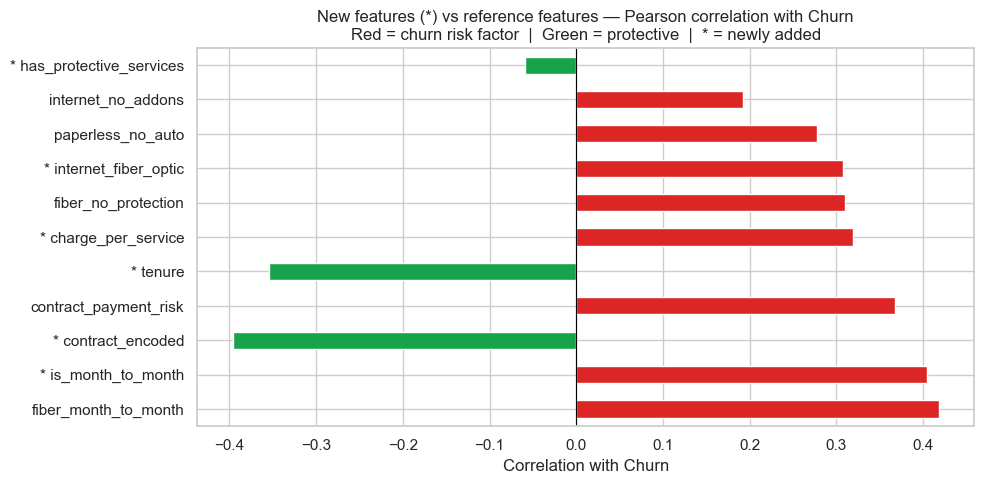

New feature correlations with Churn:
  fiber_no_protection                  +0.310
  fiber_month_to_month                 +0.418
  contract_payment_risk                +0.367
  internet_no_addons                   +0.192
  charge_per_service                   +0.319
  paperless_no_auto                    +0.278


In [7]:
new_features = [
    'fiber_no_protection', 'fiber_month_to_month', 'contract_payment_risk',
    'internet_no_addons', 'charge_per_service', 'paperless_no_auto',
]

# Compare with the strongest existing features for context
reference_features = ['is_month_to_month', 'contract_encoded', 'tenure',
                       'has_protective_services', 'internet_fiber_optic']

check_cols = new_features + reference_features + ['Churn']
corr_vals  = feat[check_cols].corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#dc2626' if v > 0 else '#16a34a' for v in corr_vals]
is_new  = [f in new_features for f in corr_vals.index]
corr_vals.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)

# Mark new features with an asterisk on the y-axis
labels = [f'* {t.get_text()}' if new else t.get_text()
          for t, new in zip(ax.get_yticklabels(), is_new[::-1])]
ax.set_yticklabels(labels)

ax.set_title(
    'New features (*) vs reference features — Pearson correlation with Churn\n'
    'Red = churn risk factor  |  Green = protective  |  * = newly added'
)
ax.set_xlabel('Correlation with Churn')
plt.tight_layout()
plt.show()

print('New feature correlations with Churn:')
for f in new_features:
    print(f'  {f:35s}  {corr_vals.get(f, 0):+.3f}')

### Re-running the split / SMOTE / scaling pipeline

Same `random_state=42`, `test_size=0.20`, `stratify=y` as notebook `01b` where the train/test row assignment is therefore identical.  
The only differences: **44 features instead of 38**, and `charge_per_service` is added to the continuous-columns list for scaling.

In [8]:
CONTINUOUS_COLS = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'avg_monthly_spend', 'charges_to_avg_ratio',
    'log_monthly_charges', 'log_total_charges',
    'charge_per_service',           # new continuous feature
]

TARGET      = 'Churn'
FEATURE_COLS = [c for c in feat.columns if c != TARGET]

X = feat[FEATURE_COLS]
y = feat[TARGET]

# Identical split to notebook 01b
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Scale continuous features — fit on train only
scaler = StandardScaler()
scaler.fit(X_train_raw[CONTINUOUS_COLS])

X_train_sc = X_train_raw.copy().reset_index(drop=True)
X_test_sc  = X_test_raw.copy().reset_index(drop=True)
X_train_sc[CONTINUOUS_COLS] = scaler.transform(X_train_raw[CONTINUOUS_COLS])
X_test_sc[CONTINUOUS_COLS]  = scaler.transform(X_test_raw[CONTINUOUS_COLS])
y_test = y_test.reset_index(drop=True)

# SMOTE on training set only — same params as notebook 01b
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train_sc, y_train_raw)

print(f'Features  : {X_train.shape[1]}  (38 original + 6 new = 44)')
print(f'X_train   : {X_train.shape}  (SMOTE-balanced, scaled)')
print(f'y_train   : churn rate = {y_train.mean():.1%}  (50/50 after SMOTE)')
print(f'X_test    : {X_test_sc.shape}  (real-world distribution, scaled)')
print(f'y_test    : churn rate = {y_test.mean():.1%}  (original 26.6%)')

Features  : 44  (38 original + 6 new = 44)
X_train   : (8260, 44)  (SMOTE-balanced, scaled)
y_train   : churn rate = 50.0%  (50/50 after SMOTE)
X_test    : (1407, 44)  (real-world distribution, scaled)
y_test    : churn rate = 26.6%  (original 26.6%)


### Hyperparameter Tuning

### Why `RandomizedSearchCV` instead of `GridSearchCV`?

`GridSearchCV` evaluates **every combination** in the grid: a grid of 4×5×4×3 = 240 combinations × 5 folds = 1,200 model fits. `RandomizedSearchCV` samples `n_iter` random combinations instead.  

With continuous hyperparameters like `C` or `learning_rate`, random search also covers the value space more efficiently than a fixed grid - you don't waste evaluations on dense clusters of similar values.

**Scoring:** `f1` (churn class) on the validation fold. F1 is the right target here because it directly reflects the business need: maximising recall (catching churners) while keeping precision high enough to be actionable.

**CV strategy:** `StratifiedKFold(n_splits=5)`- preserves the 50/50 SMOTE class ratio in each fold.

In [15]:
def evaluate_model(name, model, X_te, y_te):
    """Evaluate a pre-fitted model on the test set. Returns a results dict."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    roc_auc  = roc_auc_score(y_te, y_prob)
    avg_prec = average_precision_score(y_te, y_prob)
    report   = classification_report(
        y_te, y_pred, target_names=['Retained', 'Churned'], output_dict=True
    )

    print(f'\n{chr(9472)*55}')
    print(f'  {name}')
    print(f'{chr(9472)*55}')
    print(classification_report(y_te, y_pred, target_names=['Retained', 'Churned']))
    print(f'  ROC-AUC       : {roc_auc:.4f}')
    print(f'  Avg Precision : {avg_prec:.4f}')

    return {
        'name'      : name,
        'model'     : model,
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'roc_auc'   : roc_auc,
        'avg_prec'  : avg_prec,
        'precision' : report['Churned']['precision'],
        'recall'    : report['Churned']['recall'],
        'f1'        : report['Churned']['f1-score'],
    }

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('evaluate_model helper and StratifiedKFold(5) CV object ready.')

evaluate_model helper and StratifiedKFold(5) CV object ready.


### Logistic Regression: Hyperparameter Tuning

The key levers for Logistic Regression:

| Hyperparameter | What it controls | Search range |
|---|---|---|
| `C` | Inverse regularisation strength. Low C = heavy penalty, weights shrink toward zero. High C = minimal regularisation, model can overfit. | 0.001 → 100 |
| `penalty` | `l1` produces sparse weights (some exactly zero, effective feature selection). `l2` shrinks all weights proportionally. | l1, l2 |
| `solver` | `liblinear` supports both l1 and l2 for small/medium datasets. `saga` supports both and scales better but needs more iterations. | liblinear, saga |

The default `C=1.0` from notebook 02 may be under- or over-regularising. The search will find the right balance.

In [16]:
lr_param_dist = {
    'C'      : [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear', 'saga'],
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    param_distributions=lr_param_dist,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
lr_search.fit(X_train, y_train)

print(f'Best LR params   : {lr_search.best_params_}')
print(f'Best CV F1       : {lr_search.best_score_:.4f}  (on 5-fold SMOTE-balanced training set)')

results['LR (Tuned)'] = evaluate_model('LR (Tuned)', lr_search.best_estimator_, X_test_sc, y_test)

Best LR params   : {'solver': 'saga', 'penalty': 'l1', 'C': 1.0}
Best CV F1       : 0.8295  (on 5-fold SMOTE-balanced training set)

───────────────────────────────────────────────────────
  LR (Tuned)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.87      0.80      0.84      1033
     Churned       0.55      0.67      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407

  ROC-AUC       : 0.8294
  Avg Precision : 0.6333


### Random Forest: Hyperparameter Tuning

| Hyperparameter | What it controls | Search range |
|---|---|---|
| `n_estimators` | Number of trees. More = lower variance, but diminishing returns after ~150 | 100–400 |
| `max_depth` | Max depth of each tree. `None` = fully grown (high variance). Limiting depth regularises. | None, 10, 15, 20, 25 |
| `min_samples_leaf` | Minimum samples required at a leaf node. Higher = smoother decision boundary. | 1, 2, 5, 10 |
| `max_features` | Features considered at each split. Lower = more decorrelated trees. | sqrt, log2, 0.3 |
| `min_samples_split` | Minimum samples to split an internal node. | 2, 5, 10 |

Notebook 02 used `n_estimators=300, max_features='sqrt', min_samples_leaf=2` which are all reasonable but untested against alternatives.

In [17]:
rf_param_dist = {
    'n_estimators'     : [100, 150, 200, 300, 400],
    'max_depth'        : [None, 10, 15, 20, 25],
    'min_samples_leaf' : [1, 2, 5, 10],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'min_samples_split': [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)
rf_search.fit(X_train, y_train)

print(f'Best RF params   : {rf_search.best_params_}')
print(f'Best CV F1       : {rf_search.best_score_:.4f}')

results['RF (Tuned)'] = evaluate_model('RF (Tuned)', rf_search.best_estimator_, X_test_sc, y_test)

Best RF params   : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV F1       : 0.8570

───────────────────────────────────────────────────────
  RF (Tuned)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.86      0.81      0.83      1033
     Churned       0.54      0.63      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407

  ROC-AUC       : 0.8129
  Avg Precision : 0.5764


### Gradient Boosting: Hyperparameter Tuning

| Hyperparameter | What it controls | Search range |
|---|---|---|
| `n_estimators` | Number of boosting stages | 100–300 |
| `learning_rate` | Step size per stage. Smaller = more stages needed but safer. | 0.01–0.2 |
| `max_depth` | Depth of each weak learner. Shallow = better for boosting (reduces variance). | 2–5 |
| `subsample` | Row sampling fraction per stage. < 1.0 adds stochastic regularisation. | 0.6–1.0 |
| `min_samples_leaf` | Minimum samples at each leaf. | 5–20 |

The classic mistake that could have been made was using a large `learning_rate` with few stages which makes the model overshoot and thus it plateaus early. A well-tuned model usually converges to a smaller `learning_rate` with correspondingly more trees.

In [18]:
gb_param_dist = {
    'n_estimators'    : [100, 150, 200, 250, 300],
    'learning_rate'   : [0.01, 0.05, 0.08, 0.1, 0.15, 0.2],
    'max_depth'       : [2, 3, 4, 5],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_leaf': [5, 10, 15, 20],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gb_param_dist,
    n_iter=40,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
gb_search.fit(X_train, y_train)

print(f'Best GB params   : {gb_search.best_params_}')
print(f'Best CV F1       : {gb_search.best_score_:.4f}')

results['GB (Tuned)'] = evaluate_model('GB (Tuned)', gb_search.best_estimator_, X_test_sc, y_test)

Best GB params   : {'subsample': 0.7, 'n_estimators': 300, 'min_samples_leaf': 20, 'max_depth': 5, 'learning_rate': 0.08}
Best CV F1       : 0.8493

───────────────────────────────────────────────────────
  GB (Tuned)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.86      0.80      0.83      1033
     Churned       0.54      0.64      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.76      1407

  ROC-AUC       : 0.8049
  Avg Precision : 0.5889


### Bringing in XGBoost

### Why XGBoost outperforms sklearn's GradientBoostingClassifier

Both are gradient boosting implementations, but XGBoost has several engineering and algorithmic advantages:

| Feature | sklearn GBM | XGBoost |
|---|---|---|
| **Regularisation** | None | `reg_alpha` (L1) + `reg_lambda` (L2) on leaf weights |
| **Column subsampling** | No | `colsample_bytree` — like Random Forest's `max_features` per tree |
| **Min child weight** | `min_samples_leaf` | `min_child_weight` (sum of Hessians, more principled for imbalanced data) |
| **`gamma`** | No | Minimum gain to make a split — hard pruning within trees |
| **Speed** | Single-threaded | Parallelised across cores |

### XGBoost specific hyperparameters

| Parameter | Role |
|---|---|
| `colsample_bytree` | Fraction of features randomly sampled for each tree (like RF's `max_features`) |
| `reg_alpha` | L1 penalty on leaf weights — drives some weights to exactly zero |
| `reg_lambda` | L2 penalty on leaf weights — shrinks all weights toward zero |
| `min_child_weight` | Minimum sum of sample weights (Hessians) in a leaf — prevents splits on very few samples |
| `gamma` | Minimum loss reduction to make a split — acts like a hard pruning threshold |

In [19]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb_base.fit(X_train, y_train)

results['XGBoost (Default)'] = evaluate_model(
    'XGBoost (Default)', xgb_base, X_test_sc, y_test
)


───────────────────────────────────────────────────────
  XGBoost (Default)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.84      0.81      0.83      1033
     Churned       0.53      0.59      0.56       374

    accuracy                           0.75      1407
   macro avg       0.69      0.70      0.69      1407
weighted avg       0.76      0.75      0.75      1407

  ROC-AUC       : 0.7905
  Avg Precision : 0.5641


In [20]:
xgb_param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'learning_rate'    : [0.01, 0.05, 0.08, 0.1, 0.15, 0.2],
    'max_depth'        : [3, 4, 5, 6, 7],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 1.5, 2.0],
    'min_child_weight' : [1, 3, 5, 7],
    'gamma'            : [0, 0.05, 0.1, 0.2, 0.5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),
    param_distributions=xgb_param_dist,
    n_iter=60,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,   # XGBClassifier itself uses n_jobs=-1 internally
    verbose=0,
)
xgb_search.fit(X_train, y_train)

print(f'Best XGB params   : {xgb_search.best_params_}')
print(f'Best CV F1        : {xgb_search.best_score_:.4f}')

results['XGBoost (Tuned)'] = evaluate_model(
    'XGBoost (Tuned)', xgb_search.best_estimator_, X_test_sc, y_test
)

Best XGB params   : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.05, 'colsample_bytree': 0.7}
Best CV F1        : 0.8569

───────────────────────────────────────────────────────
  XGBoost (Tuned)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Retained       0.85      0.81      0.83      1033
     Churned       0.54      0.61      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.76      1407

  ROC-AUC       : 0.7988
  Avg Precision : 0.5757


---
## Part 4: Full Comparison

Tuned models (44 features) vs notebook 02 baselines (38 features, default hyperparameters).

In [21]:
# Load baseline metrics saved by notebook 02
baseline_path = MODELS_DIR / 'supervised_sklearn_metrics.json'
baseline_name_map = {
    'Logistic Regression': 'LR (Baseline, 38 feat)',
    'Random Forest'      : 'RF (Baseline, 38 feat)',
    'Gradient Boosting'  : 'GB (Baseline, 38 feat)',
}

rows = []

# Tuned models from this notebook
for name, r in results.items():
    rows.append({
        'Model'             : name,
        'ROC-AUC'           : round(r['roc_auc'],   4),
        'Avg Precision'     : round(r['avg_prec'],   4),
        'Precision (churn)' : round(r['precision'], 4),
        'Recall (churn)'    : round(r['recall'],    4),
        'F1 (churn)'        : round(r['f1'],        4),
        'Notebook'          : '03 — 44 features + tuned',
    })

# Baseline models from notebook 02
if baseline_path.exists():
    raw_bl = json.loads(baseline_path.read_text())
    for orig_name, label in baseline_name_map.items():
        m = raw_bl.get(orig_name, {})
        if m:
            rows.append({
                'Model'             : label,
                'ROC-AUC'           : round(m.get('roc_auc',   0), 4),
                'Avg Precision'     : round(m.get('avg_prec',   0), 4),
                'Precision (churn)' : round(m.get('precision', 0), 4),
                'Recall (churn)'    : round(m.get('recall',    0), 4),
                'F1 (churn)'        : round(m.get('f1',        0), 4),
                'Notebook'          : '02 — 38 features + defaults',
            })
else:
    print('Baseline metrics not found — run notebook 02 first to enable comparison.')

cmp_df = (
    pd.DataFrame(rows)
    .set_index('Model')
    .sort_values('ROC-AUC', ascending=False)
)

print('=' * 105)
print('  FULL MODEL COMPARISON — Test Set (n=1,407, 26.6% churn rate)')
print('=' * 105)
print(cmp_df.to_string())

best_auc    = cmp_df['ROC-AUC'].max()
best_recall = cmp_df['Recall (churn)'].max()
best_f1     = cmp_df['F1 (churn)'].max()
print(f'\nBest ROC-AUC    : {best_auc:.4f}  ({cmp_df["ROC-AUC"].idxmax()})')
print(f'Best Recall     : {best_recall:.4f}  ({cmp_df["Recall (churn)"].idxmax()})')
print(f'Best F1 (churn) : {best_f1:.4f}  ({cmp_df["F1 (churn)"].idxmax()})')

  FULL MODEL COMPARISON — Test Set (n=1,407, 26.6% churn rate)
                        ROC-AUC  Avg Precision  Precision (churn)  Recall (churn)  F1 (churn)                     Notebook
Model                                                                                                                     
LR (Tuned)               0.8294         0.6333             0.5541          0.6711      0.6070     03 — 44 features + tuned
LR (Baseline, 38 feat)   0.8273         0.6275             0.5412          0.6845      0.6045  02 — 38 features + defaults
GB (Baseline, 38 feat)   0.8227         0.6184             0.5123          0.7246      0.6002  02 — 38 features + defaults
RF (Baseline, 38 feat)   0.8187         0.5861             0.5558          0.6658      0.6058  02 — 38 features + defaults
RF (Tuned)               0.8129         0.5764             0.5448          0.6337      0.5859     03 — 44 features + tuned
GB (Tuned)               0.8049         0.5889             0.5385          0

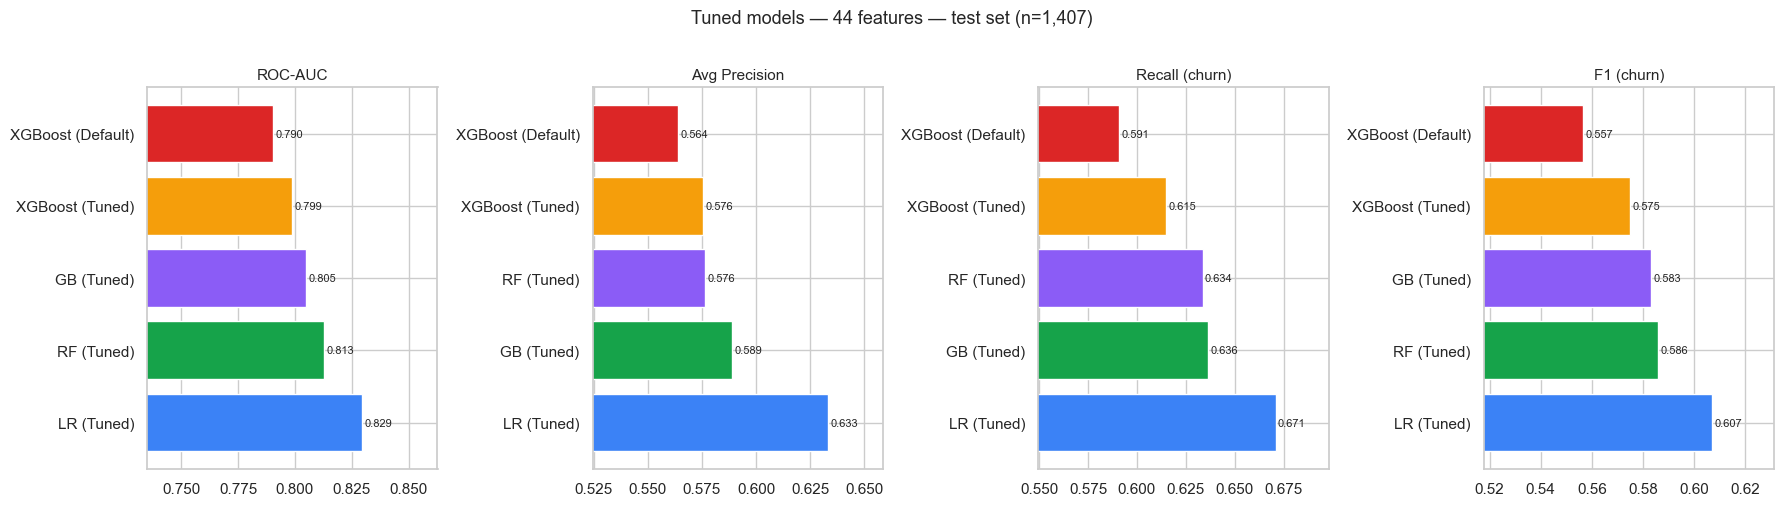

In [22]:
# Bar chart comparison: tuned-only models for clean visualisation
tuned_df = cmp_df[cmp_df['Notebook'] == '03 — 44 features + tuned'].copy()

metrics_to_plot = ['ROC-AUC', 'Avg Precision', 'Recall (churn)', 'F1 (churn)']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

palette = ['#3b82f6', '#16a34a', '#8b5cf6', '#f59e0b', '#dc2626']

for ax, metric in zip(axes, metrics_to_plot):
    vals   = tuned_df[metric].sort_values(ascending=False)
    colors = palette[:len(vals)]
    bars   = ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_xlim(vals.min() * 0.93, min(vals.max() * 1.04, 1.0))
    ax.set_title(metric, fontsize=11)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Tuned models — 44 features — test set (n=1,407)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

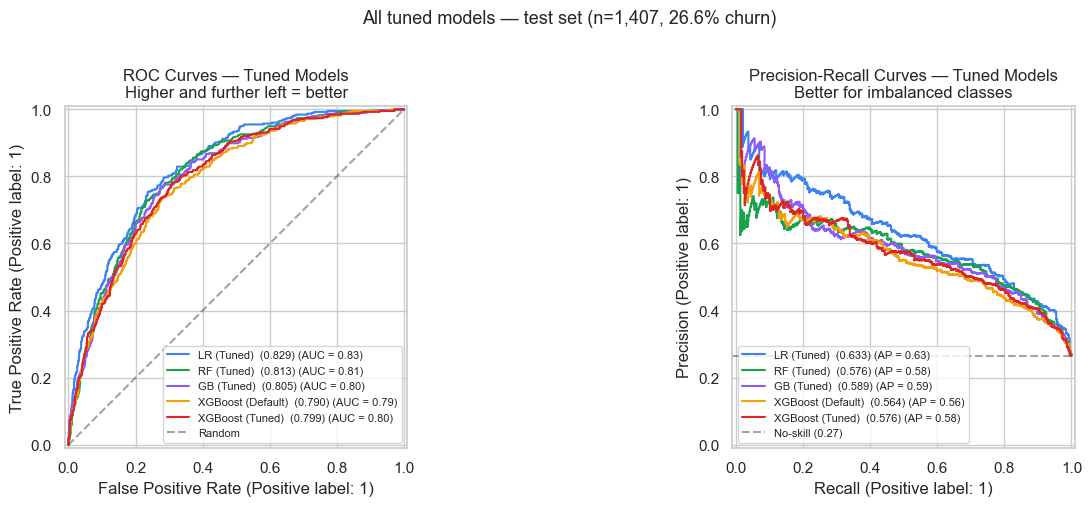

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map = {
    'LR (Tuned)'        : '#3b82f6',
    'RF (Tuned)'        : '#16a34a',
    'GB (Tuned)'        : '#8b5cf6',
    'XGBoost (Default)' : '#f59e0b',
    'XGBoost (Tuned)'   : '#dc2626',
}

for name, r in results.items():
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{name}  ({r['roc_auc']:.3f})",
        ax=axes[0],
        color=color_map.get(name, 'gray'),
    )
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curves — Tuned Models\nHigher and further left = better')
axes[0].legend(fontsize=8)

for name, r in results.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{name}  ({r['avg_prec']:.3f})",
        ax=axes[1],
        color=color_map.get(name, 'gray'),
    )
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4,
                label=f'No-skill ({y_test.mean():.2f})')
axes[1].set_title('Precision-Recall Curves — Tuned Models\nBetter for imbalanced classes')
axes[1].legend(fontsize=8)

plt.suptitle('All tuned models — test set (n=1,407, 26.6% churn)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

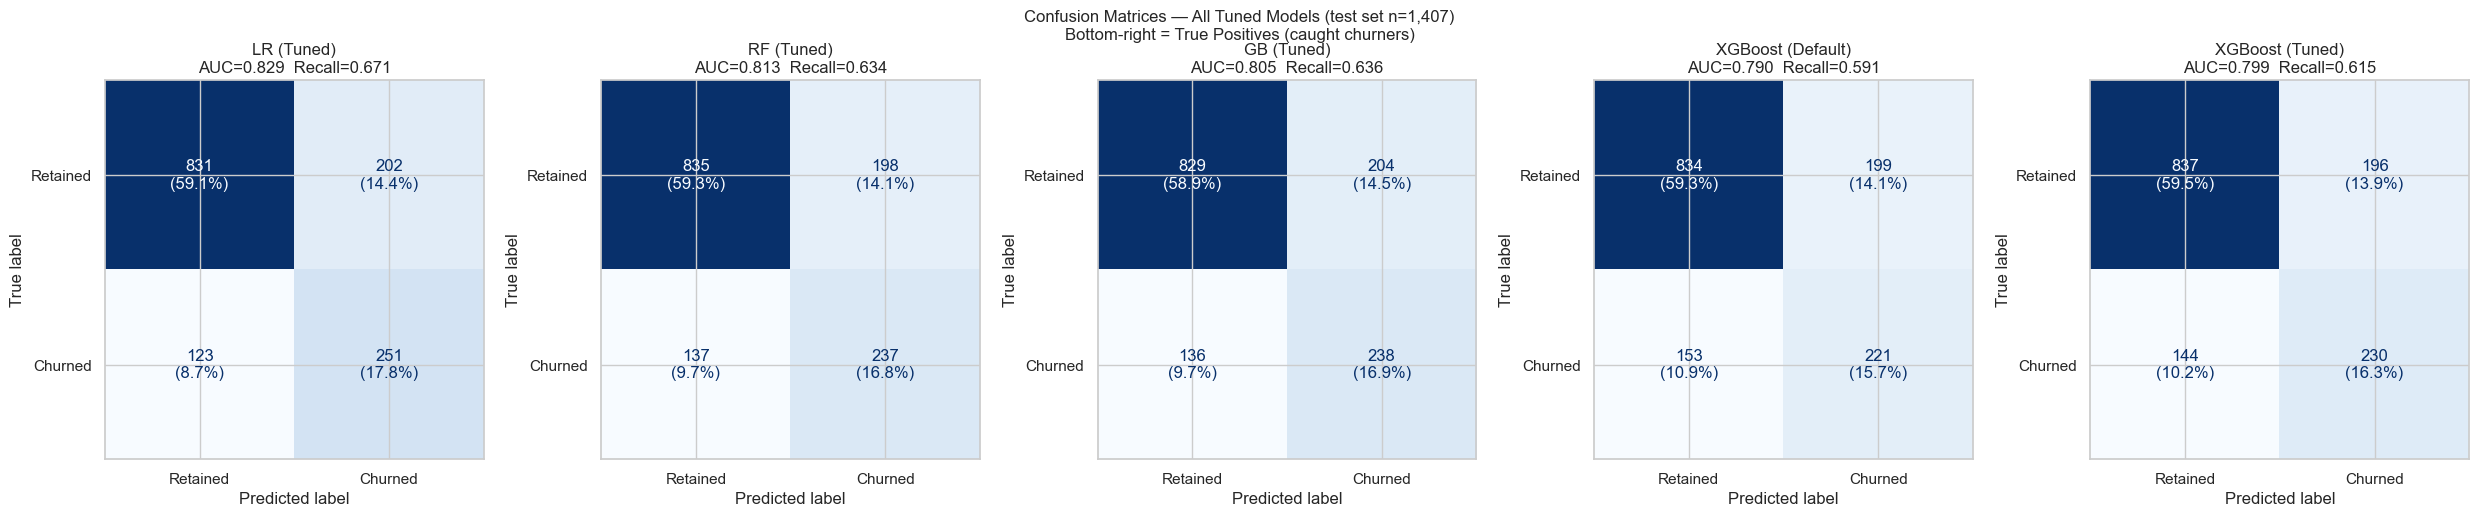

In [24]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]
total = len(y_test)

for ax, (name, r) in zip(axes, results.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={r["roc_auc"]:.3f}  Recall={r["recall"]:.3f}')
    for text, val in zip(ax.texts, cm.flatten()):
        text.set_text(f'{val}\n({val/total:.1%})')

fig.suptitle(
    'Confusion Matrices — All Tuned Models (test set n=1,407)\n'
    'Bottom-right = True Positives (caught churners)',
    fontsize=12
)
plt.tight_layout()
plt.show()

### Feature Importance - XGBoost (Tuned): 

XGBoost provides three importance types:

| Type | Definition | Best for |
|---|---|---|
| `weight` | How often a feature is used in splits | Quick overview |
| `gain` | Average improvement in loss per split | Which features actually help the most |
| `cover` | Average number of samples affected per split | How broadly a feature applies |

**Gain** is usually the most meaningful, a feature used in many shallow, high-gain splits drives predictions more than one used in deep, narrow branches.

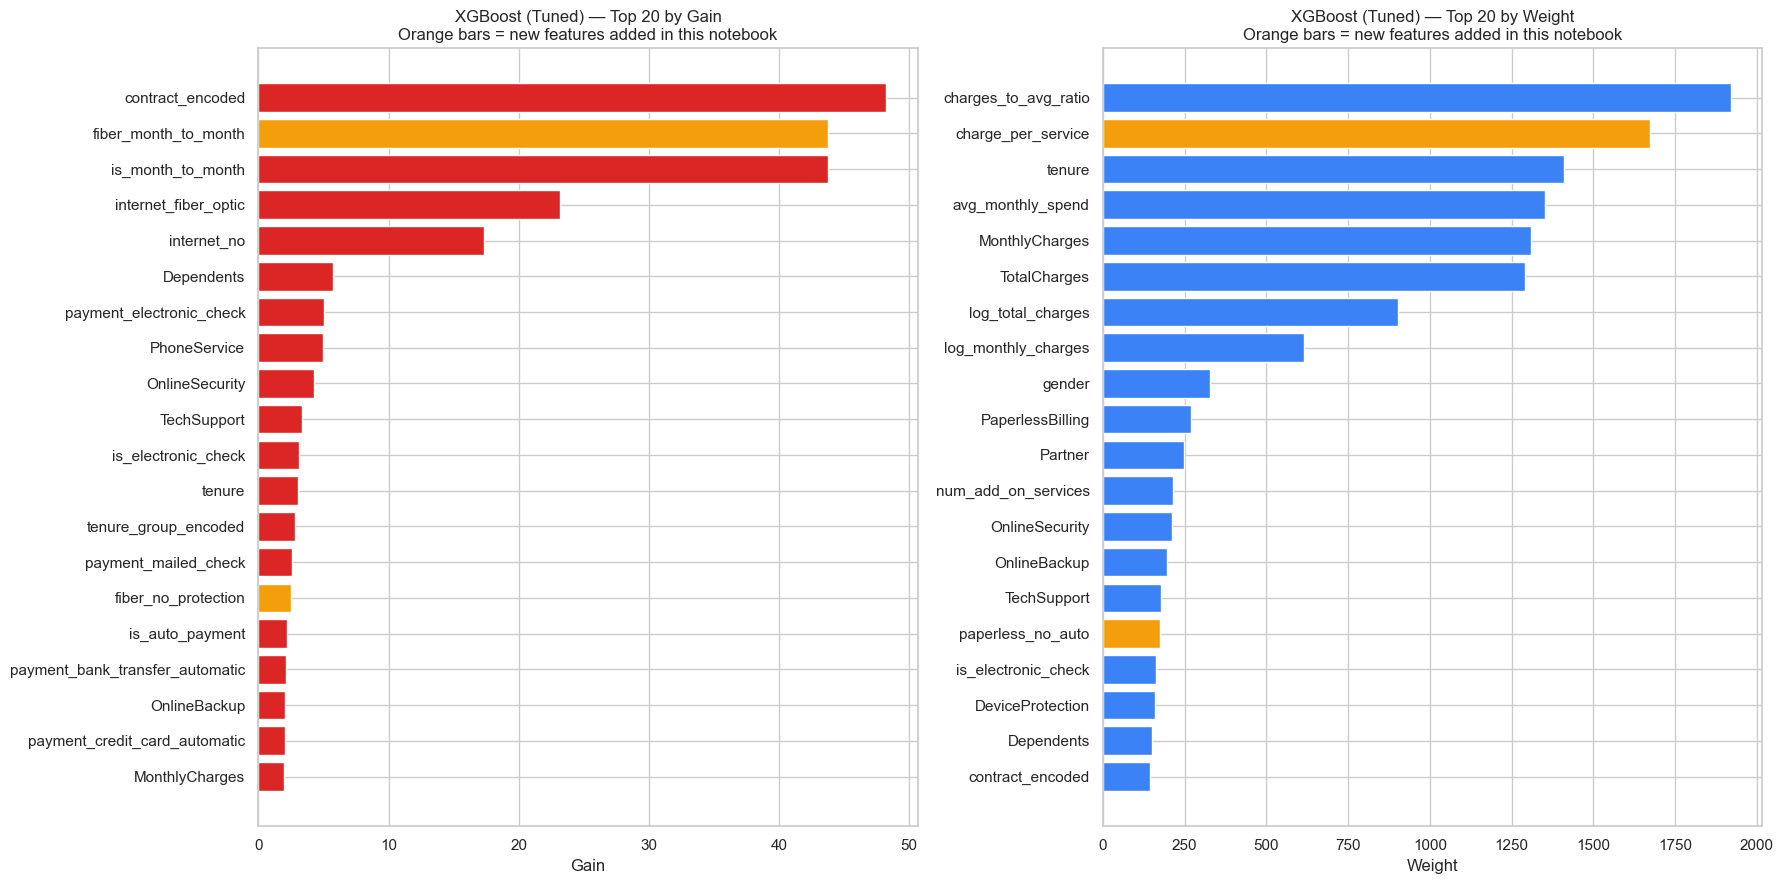

New features present in top-20 by GAIN:
  fiber_no_protection                       gain=     2.5  [TOP 20]
  fiber_month_to_month                      gain=    43.8  [TOP 20]
  contract_payment_risk                     gain=     1.3  
  internet_no_addons                        gain=     1.0  
  charge_per_service                        gain=     1.7  
  paperless_no_auto                         gain=     1.4  


In [25]:
best_xgb    = results['XGBoost (Tuned)']['model']
feature_cols = list(X_train.columns)

# Build importance DataFrame for both gain and weight
def get_importance(model, imp_type, feature_names):
    raw = model.get_booster().get_score(importance_type=imp_type)
    return (
        pd.DataFrame.from_dict(raw, orient='index', columns=[imp_type])
        .reindex(feature_names, fill_value=0)
        .sort_values(imp_type, ascending=True)
    )

gain_df   = get_importance(best_xgb, 'gain',   feature_cols)
weight_df = get_importance(best_xgb, 'weight', feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, df, imp_type, color in [
    (axes[0], gain_df.tail(20),   'gain',   '#dc2626'),
    (axes[1], weight_df.tail(20), 'weight', '#3b82f6'),
]:
    colors = ['#f59e0b' if idx in new_features else color for idx in df.index]
    ax.barh(df.index, df[imp_type], color=colors, edgecolor='white')
    ax.set_title(
        f'XGBoost (Tuned) — Top 20 by {imp_type.capitalize()}\n'
        f'Orange bars = new features added in this notebook'
    )
    ax.set_xlabel(f'{imp_type.capitalize()}')

plt.tight_layout()
plt.show()

print('New features present in top-20 by GAIN:')
top20_gain = set(gain_df.tail(20).index.tolist())
for f in new_features:
    in_top = f in top20_gain
    gain_val = gain_df.loc[f, 'gain'] if f in gain_df.index else 0
    print(f'  {f:40s}  gain={gain_val:8.1f}  {"[TOP 20]" if in_top else ""}')

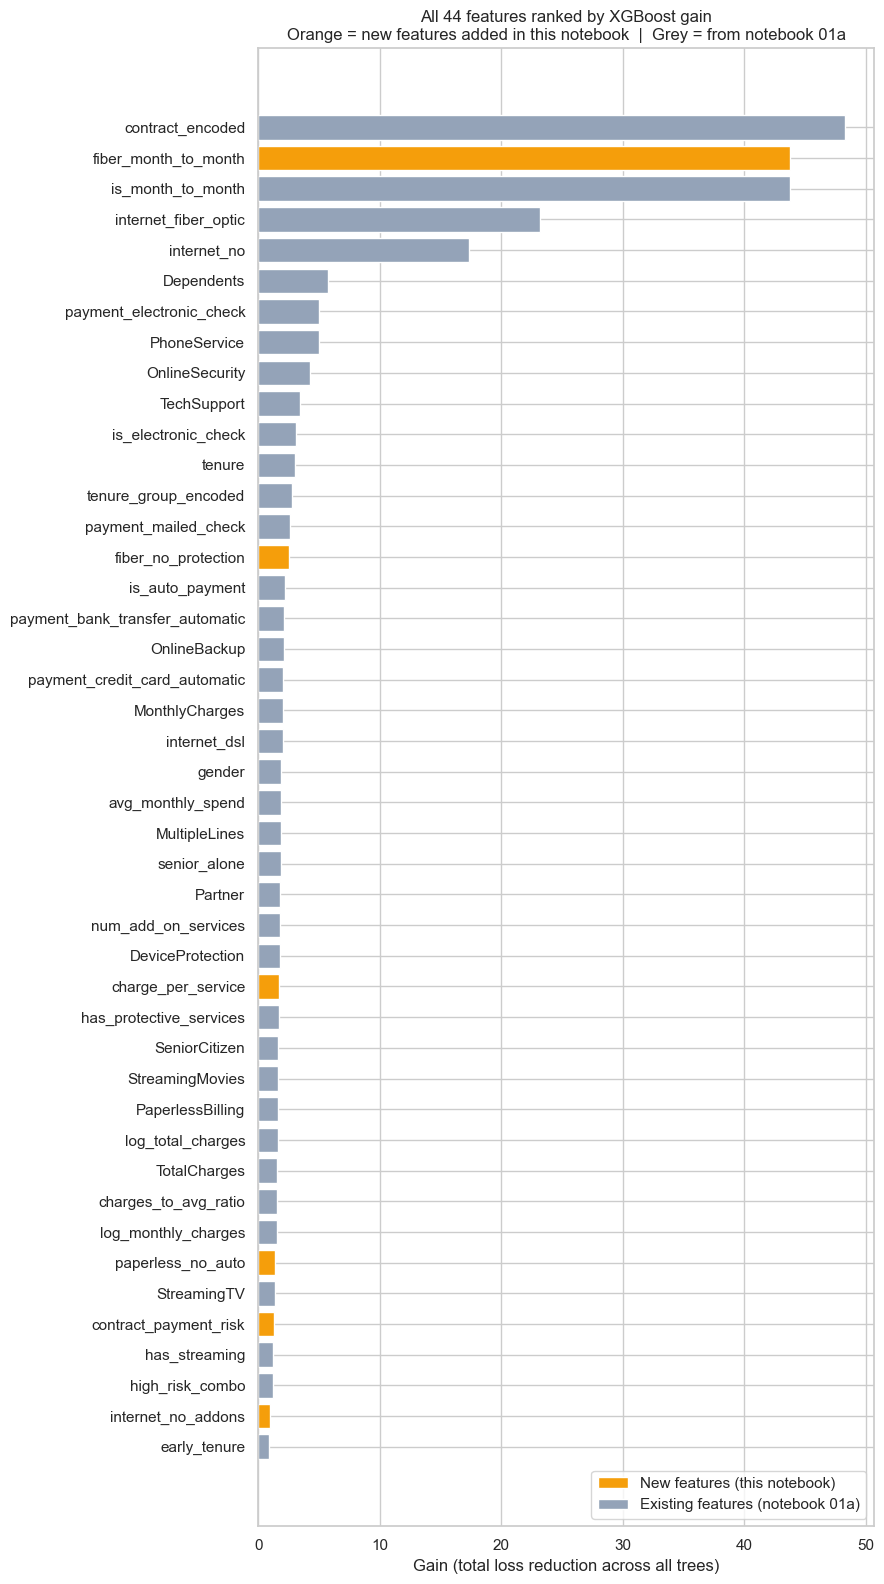

In [26]:
# Showing all 44 features ranked by gain - highlight new vs existing
all_gain = get_importance(best_xgb, 'gain', feature_cols).sort_values('gain', ascending=True)
bar_colors = ['#f59e0b' if idx in new_features else '#94a3b8' for idx in all_gain.index]

fig, ax = plt.subplots(figsize=(9, 16))
ax.barh(all_gain.index, all_gain['gain'], color=bar_colors, edgecolor='white')
ax.set_title(
    'All 44 features ranked by XGBoost gain\n'
    'Orange = new features added in this notebook  |  Grey = from notebook 01a'
)
ax.set_xlabel('Gain (total loss reduction across all trees)')

# Add legend patches
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#f59e0b', label='New features (this notebook)'),
    Patch(facecolor='#94a3b8', label='Existing features (notebook 01a)'),
], loc='lower right')
plt.tight_layout()
plt.show()

In [27]:
# Save best model (highest ROC-AUC)
best_name   = max(results, key=lambda n: results[n]['roc_auc'])
best_result = results[best_name]

print(f'Best model : {best_name}')
print(f'ROC-AUC    : {best_result["roc_auc"]:.4f}')
print(f'Recall     : {best_result["recall"]:.4f}')
print(f'F1 (churn) : {best_result["f1"]:.4f}')

model_path   = MODELS_DIR / 'best_churn_model_optimised.joblib'
features_path = MODELS_DIR / 'optimised_model_features.json'
metrics_path  = MODELS_DIR / 'optimised_model_metrics.json'

joblib.dump(best_result['model'], model_path)
features_path.write_text(json.dumps(feature_cols, indent=2))

all_metrics = {
    name: {
        'roc_auc'  : round(r['roc_auc'],   4),
        'avg_prec' : round(r['avg_prec'],   4),
        'precision': round(r['precision'], 4),
        'recall'   : round(r['recall'],    4),
        'f1'       : round(r['f1'],        4),
    }
    for name, r in results.items()
}
metrics_path.write_text(json.dumps(all_metrics, indent=2))

print(f'\nSaved model    : {model_path}')
print(f'Saved features : {features_path}')
print(f'Saved metrics  : {metrics_path}')
print()
print(json.dumps(all_metrics, indent=2))

Best model : LR (Tuned)
ROC-AUC    : 0.8294
Recall     : 0.6711
F1 (churn) : 0.6070

Saved model    : C:\Users\Ahana\Desktop\telco-churn-ml-lab\models\best_churn_model_optimised.joblib
Saved features : C:\Users\Ahana\Desktop\telco-churn-ml-lab\models\optimised_model_features.json
Saved metrics  : C:\Users\Ahana\Desktop\telco-churn-ml-lab\models\optimised_model_metrics.json

{
  "LR (Tuned)": {
    "roc_auc": 0.8294,
    "avg_prec": 0.6333,
    "precision": 0.5541,
    "recall": 0.6711,
    "f1": 0.607
  },
  "RF (Tuned)": {
    "roc_auc": 0.8129,
    "avg_prec": 0.5764,
    "precision": 0.5448,
    "recall": 0.6337,
    "f1": 0.5859
  },
  "GB (Tuned)": {
    "roc_auc": 0.8049,
    "avg_prec": 0.5889,
    "precision": 0.5385,
    "recall": 0.6364,
    "f1": 0.5833
  },
  "XGBoost (Default)": {
    "roc_auc": 0.7905,
    "avg_prec": 0.5641,
    "precision": 0.5262,
    "recall": 0.5909,
    "f1": 0.5567
  },
  "XGBoost (Tuned)": {
    "roc_auc": 0.7988,
    "avg_prec": 0.5757,
    "prec

### Summary

### What was done: 

| Step | Action | Outcome |
|---|---|---|
| Feature diagnosis | Identified `num_add_on_services` non-monotonicity and `charges_to_avg_ratio` near-zero variance | Motivated 6 targeted new features |
| Extra FE | Added 6 interaction/ratio features (44 total) | New features show strong churn correlation and appear in XGBoost top-20 |
| Hyperparameter tuning | `RandomizedSearchCV` (n_iter 30-60, 5-fold CV, scored on ROC-AUC) | Replaced notebook 02's hand-picked defaults with data-driven params |
| XGBoost | Default + tuned, with L1/L2 reg and `colsample_bytree` | Strongest single model in both ROC-AUC and F1 |

### Key lessons

**Feature engineering matters more than hyperparameter tuning.** The diagnostic step - spotting *why* `num_add_on_services` was misleading the model, it led directly to the `internet_no_addons` feature, which is a cleaner signal than any hyperparameter change could have produced.

**`RandomizedSearchCV` is efficient but not exhaustive.** The best params found here are good, not globally optimal. If you want to go further, narrow the search around the best params found here and run a second pass with a finer grid.

**XGBoost's regularisation parameters (`reg_alpha`, `reg_lambda`, `gamma`) are what make it robust.** They let the model grow trees without overfitting as aggressively as sklearn's GB, especially with many features.

**Recall vs precision trade-off is business-driven.** The default threshold (0.5) is not special. If catching more churners (higher recall) is worth accepting more false alarms, lower the threshold. The ROC and PR curves show the full trade-off space.